In [2]:
import pandas as pd

irrigation = pd.read_csv("/workspaces/farmer_crop_climate_mismatch_system/datasets/irrigation_prediction.csv")

print(irrigation.shape)
print(irrigation.columns)
print(irrigation.dtypes)

irrigation.head()

(10000, 20)
Index(['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
       'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need'],
      dtype='str')
Soil_Type                      str
Soil_pH                    float64
Soil_Moisture              float64
Organic_Carbon             float64
Electrical_Conductivity    float64
Temperature_C              float64
Humidity                   float64
Rainfall_mm                float64
Sunlight_Hours             float64
Wind_Speed_kmh             float64
Crop_Type                      str
Crop_Growth_Stage              str
Season                         str
Irrigation_Type                str
Water_Source                   str
Field_Area_hectare         float64
Mulching_Used                  str

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


In [3]:
print(irrigation.isnull().sum())

Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64


In [4]:
X = irrigation.drop("Irrigation_Need", axis=1)
y = irrigation["Irrigation_Need"]

In [5]:
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()

label_encoders = {}

for column in X_encoded.columns:
    
    if X_encoded[column].dtype == "object":
        
        le = LabelEncoder()
        
        X_encoded[column] = le.fit_transform(
            X_encoded[column].astype(str)
        )
        
        label_encoders[column] = le

# Encode target
target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(y)

print(target_encoder.classes_)

['High' 'Low' 'Medium']


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [7]:
print(X.dtypes)
for col in X.columns:
    print(col, ":", X[col].dtype)

Soil_Type                      str
Soil_pH                    float64
Soil_Moisture              float64
Organic_Carbon             float64
Electrical_Conductivity    float64
Temperature_C              float64
Humidity                   float64
Rainfall_mm                float64
Sunlight_Hours             float64
Wind_Speed_kmh             float64
Crop_Type                      str
Crop_Growth_Stage              str
Season                         str
Irrigation_Type                str
Water_Source                   str
Field_Area_hectare         float64
Mulching_Used                  str
Previous_Irrigation_mm     float64
Region                         str
dtype: object
Soil_Type : str
Soil_pH : float64
Soil_Moisture : float64
Organic_Carbon : float64
Electrical_Conductivity : float64
Temperature_C : float64
Humidity : float64
Rainfall_mm : float64
Sunlight_Hours : float64
Wind_Speed_kmh : float64
Crop_Type : str
Crop_Growth_Stage : str
Season : str
Irrigation_Type : str
Water_Source :

In [8]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

# Load dataset
irrigation = pd.read_csv("../datasets/irrigation_prediction.csv")

# Features and target
X = irrigation.drop("Irrigation_Need", axis=1)
y = irrigation["Irrigation_Need"]

# One-Hot Encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

print("Original Shape:", X.shape)
print("Encoded Shape:", X_encoded.shape)

# Encode target
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42
)

# Train model
irrigation_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

irrigation_model.fit(X_train, y_train)

# Predictions
y_pred = irrigation_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Original Shape: (10000, 19)
Encoded Shape: (10000, 35)

Accuracy: 97.75 %

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.46      0.63        59
           1       0.99      1.00      0.99      1204
           2       0.95      0.99      0.97       737

    accuracy                           0.98      2000
   macro avg       0.98      0.81      0.86      2000
weighted avg       0.98      0.98      0.97      2000



                         Feature  Importance
1                  Soil_Moisture    0.181966
8                 Wind_Speed_kmh    0.095923
6                    Rainfall_mm    0.095538
4                  Temperature_C    0.090854
20      Crop_Growth_Stage_Sowing    0.080638
19     Crop_Growth_Stage_Harvest    0.080022
30             Mulching_Used_Yes    0.072650
21  Crop_Growth_Stage_Vegetative    0.034536
9             Field_Area_hectare    0.028396
5                       Humidity    0.028335
10        Previous_Irrigation_mm    0.028017
7                 Sunlight_Hours    0.027341
0                        Soil_pH    0.027167
2                 Organic_Carbon    0.026646
3        Electrical_Conductivity    0.026321


<Figure size 1200x600 with 0 Axes>

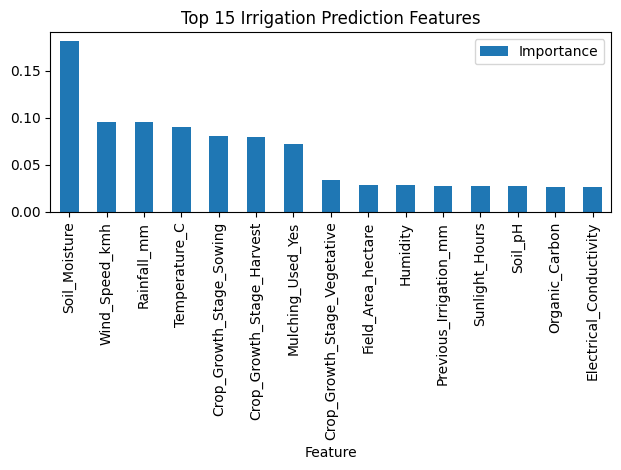

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": irrigation_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

plt.figure(figsize=(12,6))

feature_importance.head(15).plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Top 15 Irrigation Prediction Features")

plt.tight_layout()

plt.show()

In [10]:
joblib.dump(
    irrigation_model,
    "../models/irrigation_model.pkl"
)

joblib.dump(
    target_encoder,
    "../models/irrigation_target_encoder.pkl"
)

joblib.dump(
    X_encoded.columns.tolist(),
    "../models/irrigation_feature_columns.pkl"
)

print("Irrigation model saved successfully!")

Irrigation model saved successfully!
